   dataset_size  lr_train_time_cpu  lr_train_time_gpu  lr_speedup  \
0         10000           0.032084           0.045664    0.702616   
1         50000           0.317981           0.027680   11.487769   
2        100000           1.068263           0.038389   27.827345   
3        300000           1.785777           0.069164   25.819627   
4        568630           4.384530           0.202238   21.680017   

   rf_train_time_cpu  rf_train_time_gpu  rf_speedup  
0           4.751199           0.991402    4.792403  
1          24.045875           1.277468   18.823071  
2          60.165543           1.550102   38.813931  
3         241.200102           2.709825   89.009490  
4         526.309469           4.374738  120.306519  


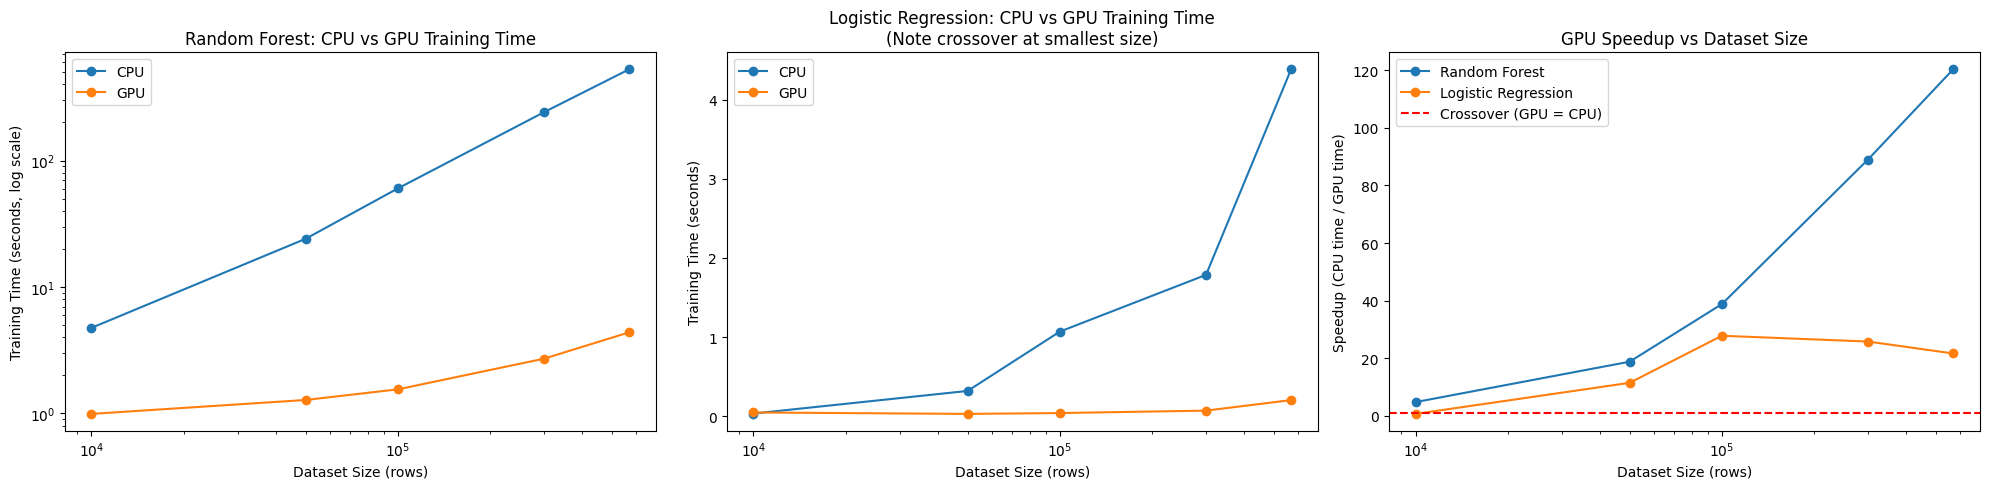


Saved final_comparison.csv and final_crossover_comparison.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

cpu = pd.read_csv('cpu_scaling_results.csv')
gpu = pd.read_csv('gpu_scaling_results.csv')

# Merge on dataset_size for direct comparison (LR and RF only — the two
# models present in both CPU and GPU runs)
merged = pd.merge(cpu, gpu, on='dataset_size', suffixes=('_cpu', '_gpu'))
merged['lr_speedup'] = merged['lr_train_time_cpu'] / merged['lr_train_time_gpu']
merged['rf_speedup'] = merged['rf_train_time_cpu'] / merged['rf_train_time_gpu']

merged.to_csv('final_comparison.csv', index=False)
print(merged[['dataset_size', 'lr_train_time_cpu', 'lr_train_time_gpu', 'lr_speedup',
              'rf_train_time_cpu', 'rf_train_time_gpu', 'rf_speedup']])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Plot 1: Random Forest, CPU vs GPU (log scale — huge gap)
axes[0].plot(merged['dataset_size'], merged['rf_train_time_cpu'], marker='o', label='CPU')
axes[0].plot(merged['dataset_size'], merged['rf_train_time_gpu'], marker='o', label='GPU')
axes[0].set_xlabel('Dataset Size (rows)')
axes[0].set_ylabel('Training Time (seconds, log scale)')
axes[0].set_title('Random Forest: CPU vs GPU Training Time')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].legend()

# Plot 2: Logistic Regression, CPU vs GPU
axes[1].plot(merged['dataset_size'], merged['lr_train_time_cpu'], marker='o', label='CPU')
axes[1].plot(merged['dataset_size'], merged['lr_train_time_gpu'], marker='o', label='GPU')
axes[1].set_xlabel('Dataset Size (rows)')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Logistic Regression: CPU vs GPU Training Time\n(Note crossover at smallest size)')
axes[1].set_xscale('log')
axes[1].legend()

# Plot 3: Speedup factor (the "crossover" view — the single most important chart)
axes[2].plot(merged['dataset_size'], merged['rf_speedup'], marker='o', label='Random Forest')
axes[2].plot(merged['dataset_size'], merged['lr_speedup'], marker='o', label='Logistic Regression')
axes[2].axhline(y=1, color='red', linestyle='--', label='Crossover (GPU = CPU)')
axes[2].set_xlabel('Dataset Size (rows)')
axes[2].set_ylabel('Speedup (CPU time / GPU time)')
axes[2].set_title('GPU Speedup vs Dataset Size')
axes[2].set_xscale('log')
axes[2].legend()

plt.tight_layout()
plt.savefig('final_crossover_comparison.png', dpi=150)
plt.show()

print("\nSaved final_comparison.csv and final_crossover_comparison.png")